# Sentinel-1 Ocean Radial Velocity Layer: Step-by-Step Pipeline

This notebook goes through the ESA OCN RVL algorithm (following Engen & Johnsen, DI-MPC-RVL-0534) for a single IW TOPS burst. Intermediate result of each step are plotted to make it easier to follow what is happening.

Scene: S1A IW, 2026-02-05 around 16:52 UTC, South-West Indian Ocean off South Africa  
Subswath: IW1, burst index 3  
Corrections applied: AUX_CAL (ambiguity and sideband bias), geometry Doppler from POEORB precision orbit, ERA5 Stokes drift, ERA5 wave Doppler bias, OCN rvlDcMiss for mispointing  
Reference model: CMEMS GLO12 (uo, vo)

Here is a rough overview of all the steps:

| Step | What happens |
|------|--------------|
| I    | Deramp the TOPS burst to remove the Doppler frequency sweep |
| II   | Estimate the lag-0 and lag-1 azimuth correlation (p₀, p₁) per block |
| III  | Convert p₁ to a Doppler centroid and subtract the geometry Doppler from POEORB; mispointing is not corrected here |
| V    | Geolocate the estimation grid to get lat/lon and incidence angle |
| +    | Subtract Stokes drift and wave Doppler bias |
| +    | Apply OCN rvlDcMiss mispointing correction to get the ocean current radial velocity |
| +    | Compare the result against GLO12 model currents |

In [520]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# ── Data paths ──────────────────────────────────────────────────────────────
ROOT        = os.path.dirname(os.getcwd())          # repo root
DATA        = os.path.join(ROOT, 'data')

SLC_SAFE    = os.path.join(DATA, 'sentinel-1',
    'S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE')
AUX_CAL     = os.path.join(DATA, 'sentinel-1',
    'S1A_AUX_CAL_V20190228T092500_G20240327T102320.SAFE')
POEORB      = os.path.join(DATA, 'sentinel-1',
    'S1A_OPER_AUX_POEORB_OPOD_20260225T070420_V20260204T225942_20260206T005942.EOF')
ERA5_WIND   = os.path.join(DATA, 'era5_data', 'data_stream-oper_stepType-instant.nc')
ERA5_WAVE   = os.path.join(DATA, 'era5_data', 'data_stream-wave_stepType-instant.nc')
GLO12       = os.path.join(DATA, 'era5_data',
    'glo12_rg_1h-m_20260205-20260205_2D_hcst_R20260218.nc')

SUBSWATH    = 'iw1'
BURST_IDX   = 0
POL         = 'vv'

print('All paths exist:', all(os.path.exists(p)
    for p in [SLC_SAFE, AUX_CAL, POEORB, ERA5_WIND, ERA5_WAVE, GLO12]))

All paths exist: True


## 1. Reading the annotation and the raw SLC burst

The annotation XML has all the metadata needed: orbit state vectors, burst timing, PRF, wavelength, geometry Doppler polynomials and the geolocation grid. The measurement TIFF is a complex array stored as int16 pairs. read_slc_burst is used to load one burst window, which comes out as an array of shape (linesPerBurst, samplesPerBurst).

In [521]:
from scripts.s1_io import find_safe_files, parse_annotation, read_slc_burst
from scripts.s1_aux import parse_aux_cal, apply_poeorb

files          = find_safe_files(SLC_SAFE, SUBSWATH, POL)
annot_original = parse_annotation(files['annotation'])
annot          = apply_poeorb(annot_original, POEORB)

burst = annot.bursts[BURST_IDX]
raw   = read_slc_burst(files['measurement'], annot, BURST_IDX)

print(f'Subswath : {annot.subswath}')
print(f'PRF      : {annot.prf:.3f} Hz')
print(f'Wavelength: {annot.wavelength*100:.2f} cm  (f₀ = {annot.radar_frequency/1e9:.3f} GHz)')
print(f'Burst {BURST_IDX} time: {burst.azimuth_time}')
print(f'Burst shape: {raw.shape}  (lines × samples)')

Subswath : IW1
PRF      : 486.486 Hz
Wavelength: 5.55 cm  (f₀ = 5.405 GHz)
Burst 0 time: 2026-02-05 16:52:51.616345+00:00
Burst shape: (1494, 21464)  (lines × samples)


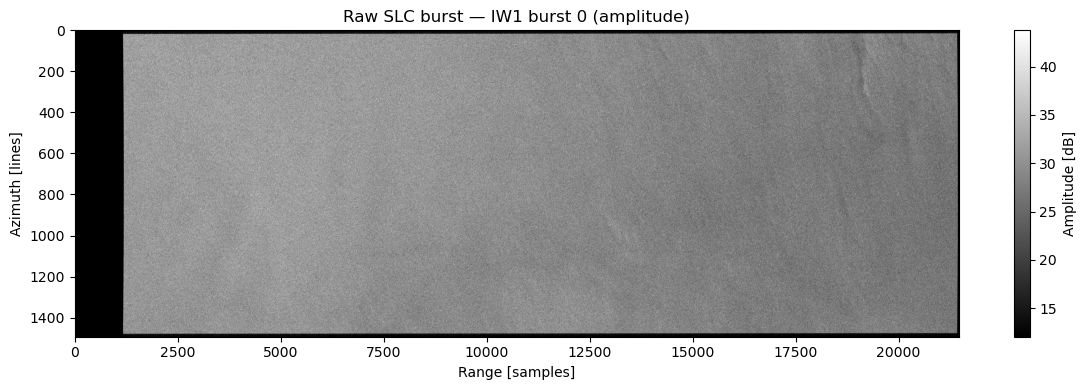

In [522]:
fig, ax = plt.subplots(figsize=(12, 4))
amp = 20 * np.log10(np.abs(raw.astype(np.float32)) + 1)
im  = ax.imshow(amp, aspect='auto', cmap='gray',
                vmin=np.percentile(amp[amp > 0], 5),
                vmax=np.percentile(amp[amp > 0], 99))
plt.colorbar(im, ax=ax, label='Amplitude [dB]')
ax.set_title(f'Raw SLC burst — {SUBSWATH.upper()} burst {BURST_IDX} (amplitude)')
ax.set_xlabel('Range [samples]')
ax.set_ylabel('Azimuth [lines]')
plt.tight_layout()
plt.show()

## Step I: Deramping the TOPS burst

In TOPS mode the antenna sweeps forward in azimuth during each burst, which adds a linear frequency ramp to the signal as a function of azimuth time. This ramp needs to be removed before anything else. The deramp chirp does that:

$$I_\text{cbd}(t_\text{az}, \tau) = I_\text{cb}(t_\text{az}, \tau) \cdot \exp\!\left(i\pi\, k_s(\tau)\, t_\text{az}^2\right)$$

The chirp rate $k_s$ varies with range sample:
$$k_s = -\frac{k_a \, k_\psi}{k_a - k_\psi}$$

where $k_a$ is the azimuth FM rate and $k_\psi$ is the TOPS steering Doppler rate. After deramping, a stationary ocean surface target should have a flat azimuth phase. Any remaining phase slope comes from actual motion of the surface.

In [523]:
from scripts.s1_rvl import (
    deramp_burst, _deramp_rate, _fm_rate_at_burst, _steering_doppler_rate,
)

k_a   = _fm_rate_at_burst(annot, BURST_IDX)
k_psi = _steering_doppler_rate(annot, BURST_IDX)
k_s   = _deramp_rate(annot, BURST_IDX)

print(f'Azimuth FM rate k_a:    {k_a.mean():.1f} Hz/s  (negative: downchirp)')
print(f'TOPS steering rate k_ψ: {k_psi:.1f} Hz/s')
print(f'Deramp chirp rate k_s:  {k_s.mean():.1f} Hz/s  (range-dependent)')

deramped = deramp_burst(raw, annot, BURST_IDX)

# Zero invalid (ramp-up/ramp-down) lines
valid_lines = burst.first_valid_sample != -1
deramped[~valid_lines, :] = 0.0
print(f'Valid lines: {valid_lines.sum()} / {len(valid_lines)}')

Azimuth FM rate k_a:    -2257.4 Hz/s  (negative: downchirp)
TOPS steering rate k_ψ: 7590.2 Hz/s
Deramp chirp rate k_s:  -1739.8 Hz/s  (range-dependent)
Valid lines: 1455 / 1494


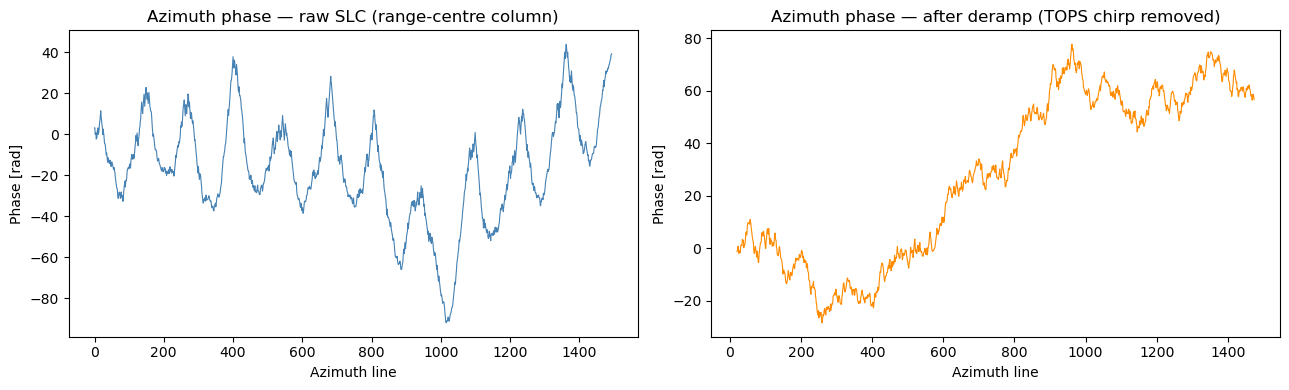

The parabolic sweep in the raw phase is removed by deramping.


In [524]:
# Show azimuth phase before / after deramping at range centre column
mid_rg = raw.shape[1] // 2
az_lines = np.arange(raw.shape[0])

phase_raw   = np.angle(raw[:, mid_rg])
phase_deramp = np.angle(deramped[:, mid_rg])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(az_lines, np.unwrap(phase_raw), lw=0.8, color='steelblue')
axes[0].set_title('Azimuth phase — raw SLC (range-centre column)')
axes[0].set_xlabel('Azimuth line')
axes[0].set_ylabel('Phase [rad]')

axes[1].plot(az_lines[valid_lines], np.unwrap(phase_deramp[valid_lines]),
             lw=0.8, color='darkorange')
axes[1].set_title('Azimuth phase — after deramp (TOPS chirp removed)')
axes[1].set_xlabel('Azimuth line')
axes[1].set_ylabel('Phase [rad]')

plt.tight_layout()
plt.show()
print('The parabolic sweep in the raw phase is removed by deramping.')

## Step II: Estimating the azimuth correlation coefficients (p₀, p₁)

The deramped image is split into overlapping blocks. For each block the lag-0 and lag-1 azimuth correlation coefficients are computed using a two-stage Hanning-windowed estimator as described in Section 5.5.1, equations 12 and 13 of the ESA OCN algortihm description.

Stage 1 works along azimuth for each range column:
$$g_0(t') = \sum_\tau |I_w(t',\tau)|^2, \qquad g_1(t') = \sum_\tau I_w(t',\tau)\,I_w^*(t',\tau-1)$$

Stage 2 averages over range using Hanning squared weights:
$$p_0 = \frac{\sum_{t'} h^2_{\text{ra}}(t')\,g_0(t')}{\sum_{t'} h^2_{\text{ra}}(t')}, \qquad p_1 = \frac{\sum_{t'} h^2_{\text{ra}}(t')\,g_1(t')}{\sum_{t'} h^2_{\text{ra}}(t')}$$

The coherence $\rho = |p_1|/p_0$ tells us how good the signal quality is. The SNR then follows as $\rho/(1-\rho)$.

In [525]:
from scripts.s1_rvl import estimate_correlation_grid

BLOCK_AZ  = 256
BLOCK_RG  = 512
STRIDE_AZ = 128
STRIDE_RG = 256

p0, p1, az_local, rg_centers = estimate_correlation_grid(
    deramped, BLOCK_AZ, BLOCK_RG, STRIDE_AZ, STRIDE_RG,
)

coherence = np.abs(p1) / np.where(p0 > 0, p0, np.nan)

print(f'Estimation grid: {p0.shape}  (az_cells × rg_cells)')
print(f'p0  range: [{np.nanmin(p0):.2e}, {np.nanmax(p0):.2e}]')
print(f'|p1| range: [{np.nanmin(np.abs(p1)):.2e}, {np.nanmax(np.abs(p1)):.2e}]')
print(f'Coherence ρ median: {np.nanmedian(coherence):.4f}')

Estimation grid: (10, 82)  (az_cells × rg_cells)
p0  range: [1.42e+01, 6.13e+01]
|p1| range: [0.00e+00, 3.96e+01]
Coherence ρ median: 0.6332


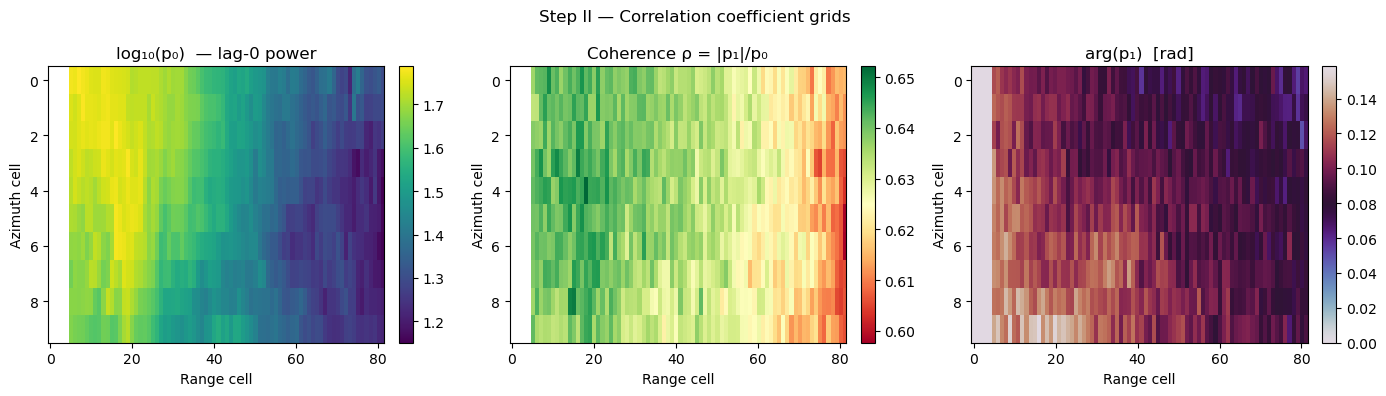

In [526]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title, cmap in zip(
    axes,
    [np.log10(p0 + 1e-10), np.abs(p1) / np.where(p0 > 0, p0, np.nan), np.angle(p1)],
    ['log₁₀(p₀)  — lag-0 power', 'Coherence ρ = |p₁|/p₀', 'arg(p₁)  [rad]'],
    ['viridis', 'RdYlGn', 'twilight'],
):
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Range cell')
    ax.set_ylabel('Azimuth cell')

plt.suptitle('Step II — Correlation coefficient grids', fontsize=12)
plt.tight_layout()
plt.show()

## Step III: Getting the Doppler centroid from p₁

The observed Doppler centroid can be recovered from the phase of $p_1$:

$$f_\text{dc} = \frac{\text{PRF}}{2\pi}\,\arg(p_1)$$

Using the AUX_CAL antenna pattern the ambiguity correction from equation 9 is applied, which accounts for power leaking in from azimuth ambiguities:

$$f_\text{dc} \leftarrow f_\text{dc} \cdot \frac{1}{1 + \gamma/\beta}, \qquad \beta = \frac{\rho}{1-\rho}$$

There is also a sideband bias to subtract, which is the gain-weighted Doppler offset of the ambiguity sidebands.

In [ ]:
from scripts.s1_rvl import (
    correlation_to_doppler, compute_gamma_ambiguity,
    compute_sideband_bias, _interpolate_orbit,
)

aap = parse_aux_cal(AUX_CAL, SUBSWATH, POL)

_, vel = _interpolate_orbit(annot, burst.azimuth_time)
v_eff  = float(np.linalg.norm(vel))
print(f'Satellite speed v_eff: {v_eff:.1f} m/s')

gamma_amb  = compute_gamma_ambiguity(aap, annot.radar_prf, v_eff, annot.wavelength)
f_sideband = compute_sideband_bias(aap, 0.0, annot.radar_prf, v_eff, annot.wavelength)
print(f'Azimuth ambiguity ratio γ:  {gamma_amb:.5f}')
print(f'Sideband bias:              {f_sideband:.3f} Hz  ({annot.wavelength/2*f_sideband*100:.2f} cm/s)')

f_dc, _, snr = correlation_to_doppler(
    p0, p1, annot.prf, annot.wavelength, gamma_amb=gamma_amb,
)

print(f'\nObserved Doppler f_dc:')
print(f'  median: {np.nanmedian(f_dc):+.1f} Hz   std: {np.nanstd(f_dc):.1f} Hz')

Satellite speed v_eff: 7583.5 m/s
Azimuth ambiguity ratio γ:  0.00000
Sideband bias:              0.000 Hz  (0.00 cm/s)

Observed Doppler f_dc:
  median: +7.3 Hz   std: 2.3 Hz


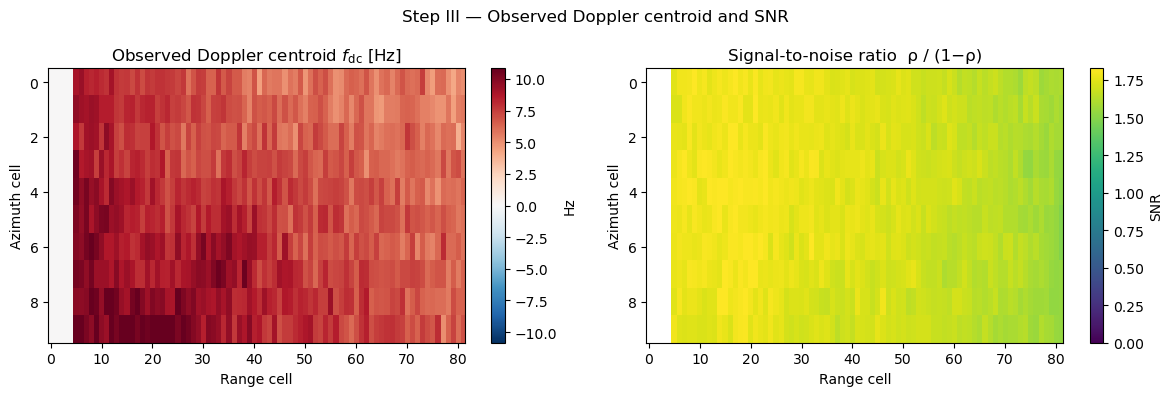

In [528]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vmax = np.nanpercentile(np.abs(f_dc), 98)
im0 = axes[0].imshow(f_dc, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im0, ax=axes[0], label='Hz')
axes[0].set_title('Observed Doppler centroid $f_\\mathrm{dc}$ [Hz]')
axes[0].set_xlabel('Range cell'); axes[0].set_ylabel('Azimuth cell')

vmax_snr = np.nanpercentile(snr[np.isfinite(snr)], 98)
im1 = axes[1].imshow(snr, aspect='auto', cmap='viridis', vmin=0, vmax=vmax_snr)
plt.colorbar(im1, ax=axes[1], label='SNR')
axes[1].set_title('Signal-to-noise ratio  ρ / (1−ρ)')
axes[1].set_xlabel('Range cell'); axes[1].set_ylabel('Azimuth cell')

plt.suptitle('Step III — Observed Doppler centroid and SNR', fontsize=12)
plt.tight_layout()
plt.show()

## Step III (cont.): Subtracting the geometry Doppler using POEORB

The geometry Doppler $f_\text{geom}$ is the Doppler centroid that a completely stationary ocean surface target would produce. It comes entirely from the satellite orbit and the radar look geometry.

When a POEORB file is available the geometry Doppler is computed by correcting the annotation polynomial with the more accurate post-processed orbit velocity:

$$f_\text{geom,POEORB}(\tau) = f_\text{geom,ann}(\tau) + \frac{2}{\lambda}\,\bigl(\mathbf{v}_\text{POEORB} - \mathbf{v}_\text{ann}\bigr) \cdot \hat{l}(\tau)$$

Here $\hat{l}$ is the ECEF unit look vector from satellite to ground. The annotation polynomial provides the base value and the POEORB velocity difference adds the orbit precision correction on top. This is then subtracted from the observed Doppler to get the Doppler centroid anomaly:

$$f_\text{dca} = f_\text{dc} - f_\text{geom,POEORB}$$

Note that antenna mispointing is not corrected here. That needs the OCN rvlDcMiss term which is applied later.

In [529]:
from scripts.s1_rvl import _geom_doppler_annotation, _geom_doppler_poeorb

# Full-scene azimuth line indices (needed for geolocation in Step V)
ati      = annot.azimuth_time_interval
az0_full = int(round(
    (burst.azimuth_time - annot.first_line_time).total_seconds() / ati
))
az_full = az_local + az0_full

# Annotation polynomial — range-only, for diagnostic comparison only
f_geom_ann = _geom_doppler_annotation(annot_original, BURST_IDX, rg_centers).astype(np.float32)

# Full POEORB-based geometry Doppler — used for the actual DCA computation
f_geom_poe = _geom_doppler_poeorb(annot, annot_original, BURST_IDX, rg_centers).astype(np.float32)

# Subtract POEORB geometry directly from observed f_dc (annotation polynomial not used)
f_dca = f_dc - f_geom_poe[np.newaxis, :]
f_dca = f_dca - float(f_sideband)

f_miss = f_geom_poe - f_geom_ann   # POEORB improvement over annotation

print('Geometry Doppler comparison (range-only, Hz):')
print(f'  Annotation polynomial :  {f_geom_ann.min():.3f} … {f_geom_ann.max():.3f}')
print(f'  POEORB-based          :  {f_geom_poe.min():.3f} … {f_geom_poe.max():.3f}')
print(f'  Differential f_miss   :  mean = {f_miss.mean():.4f} Hz'
      f'  ({annot.wavelength/2*f_miss.mean()*100:.3f} cm/s)')
print(f'\nDCA after POEORB geometry subtraction:')
print(f'  median: {np.nanmedian(f_dca):+.2f} Hz   std: {np.nanstd(f_dca):.2f} Hz')

Geometry Doppler comparison (range-only, Hz):
  Annotation polynomial :  0.589 … 0.765
  POEORB-based          :  0.536 … 0.720
  Differential f_miss   :  mean = -0.0499 Hz  (-0.138 cm/s)

DCA after POEORB geometry subtraction:
  median: +6.72 Hz   std: 2.30 Hz


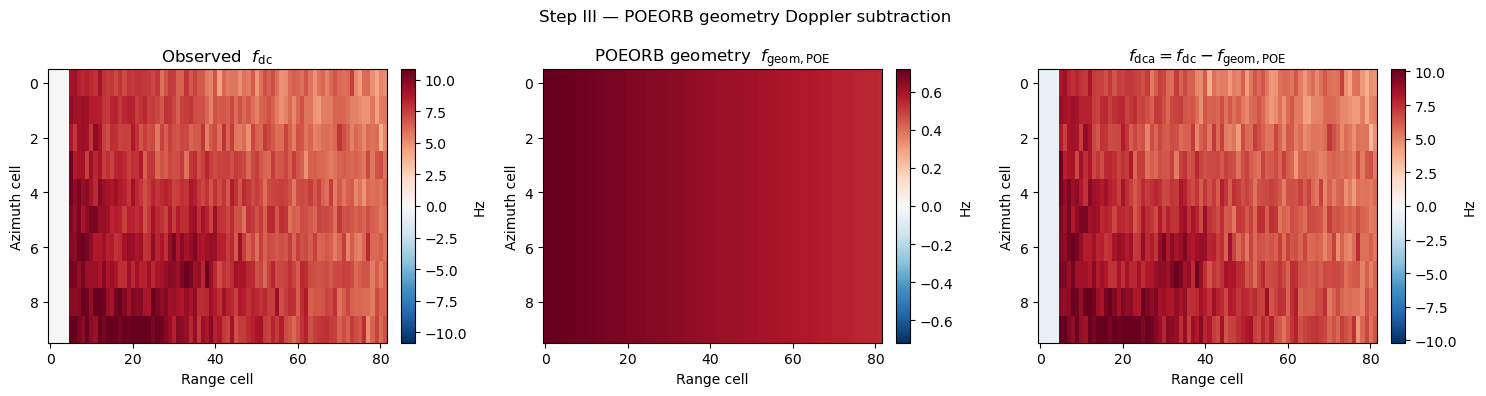

In [530]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

f_geom_poe_2d = np.broadcast_to(f_geom_poe[np.newaxis, :], f_dc.shape).copy()

panels = [
    (f_dc,          'Observed  $f_\\mathrm{dc}$'),
    (f_geom_poe_2d, 'POEORB geometry  $f_\\mathrm{geom,POE}$'),
    (f_dca,         '$f_\\mathrm{dca} = f_\\mathrm{dc} - f_\\mathrm{geom,POE}$'),
]

for ax, (data, title) in zip(axes, panels):
    vmax = np.nanpercentile(np.abs(data), 98)
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Hz', fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('Step III — POEORB geometry Doppler subtraction', fontsize=12)
plt.tight_layout()
plt.show()

### Annotation polynomial vs POEORB: orbit precision check

The annotation polynomial uses on-board state vectors that were available at product generation time. POEORB uses post-processed orbit data that becomes available a few weeks after acquisition and is considerably more accurate.

Their difference shows how much the orbit velocity improved between the two:

$$\Delta f_\text{orb}(\tau) = f_\text{geom,POEORB}(\tau) - f_\text{geom,ann}(\tau) = \frac{2}{\lambda}\,\bigl(\mathbf{v}_\text{POEORB} - \mathbf{v}_\text{ann}\bigr) \cdot \hat{l}(\tau)$$

As the output below shows, this difference is really small, around 0.003 Hz or about 0.01 cm/s. It is not the antenna mispointing. The actual mispointing from OCN rvlDcMiss is on the order of 8 to 14 Hz, which is orders of magnitude larger and has to be applied as a separate correction.

In [531]:
# Mispointing differential: POEORB improvement over annotation polynomial
f_miss_2d     = np.broadcast_to(f_miss[np.newaxis, :],     f_dca.shape).copy()
f_geom_ann_2d = np.broadcast_to(f_geom_ann[np.newaxis, :], f_dca.shape).copy()

v_miss = annot.wavelength / 2.0 * f_miss
print('POEORB improvement over annotation polynomial (diagnostic only):')
print(f'  f_miss range:        [{f_miss.min():.4f}, {f_miss.max():.4f}] Hz')
print(f'  velocity equivalent: {v_miss.mean()*100:.4f} cm/s (mean)')
print(f'  Already incorporated into f_geom_poe — not applied separately.')

POEORB improvement over annotation polynomial (diagnostic only):
  f_miss range:        [-0.0535, -0.0458] Hz
  velocity equivalent: -0.1384 cm/s (mean)
  Already incorporated into f_geom_poe — not applied separately.


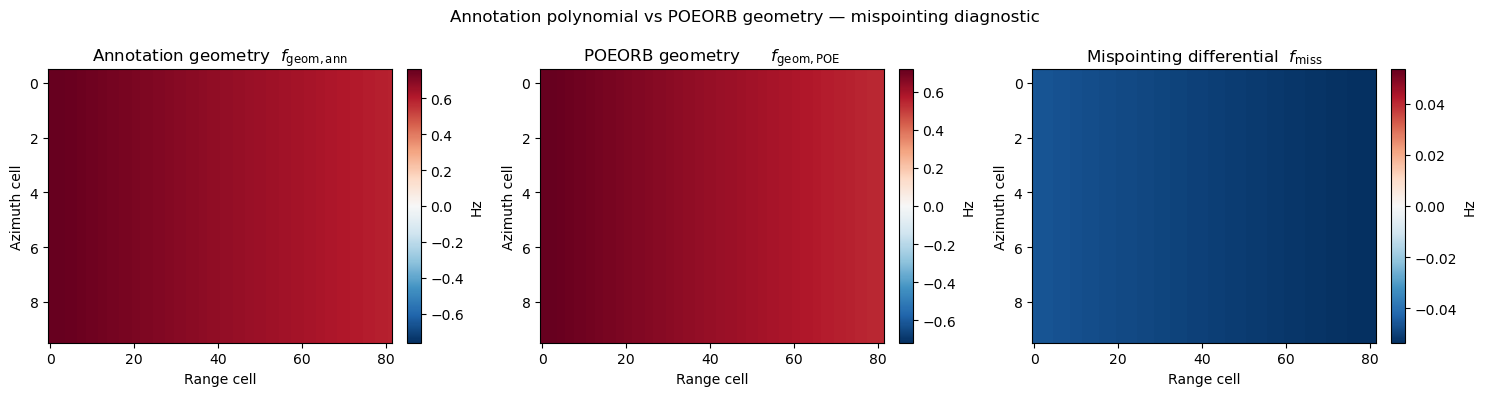

In [532]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

panels = [
    (f_geom_ann_2d, 'Annotation geometry  $f_\\mathrm{geom,ann}$'),
    (f_geom_poe_2d, 'POEORB geometry      $f_\\mathrm{geom,POE}$'),
    (f_miss_2d,     'Mispointing differential  $f_\\mathrm{miss}$'),
]

for ax, (data, title) in zip(axes, panels):
    vmax = np.nanpercentile(np.abs(data), 98) or 0.01
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Hz', fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('Annotation polynomial vs POEORB geometry — mispointing diagnostic', fontsize=12)
plt.tight_layout()
plt.show()

## SAR radial velocity

Now the Doppler centroid anomaly is converted to a radial velocity. Positive means toward the satellite:

$$v_r = \frac{\lambda}{2}\, f_\text{dca}$$

In [533]:
v_r = (annot.wavelength / 2.0 * f_dca).astype(np.float32)

print(f'Radial velocity v_r  (toward-satellite positive):')
print(f'  median: {np.nanmedian(v_r):+.3f} m/s   std: {np.nanstd(v_r):.3f} m/s')

Radial velocity v_r  (toward-satellite positive):
  median: +0.186 m/s   std: 0.064 m/s


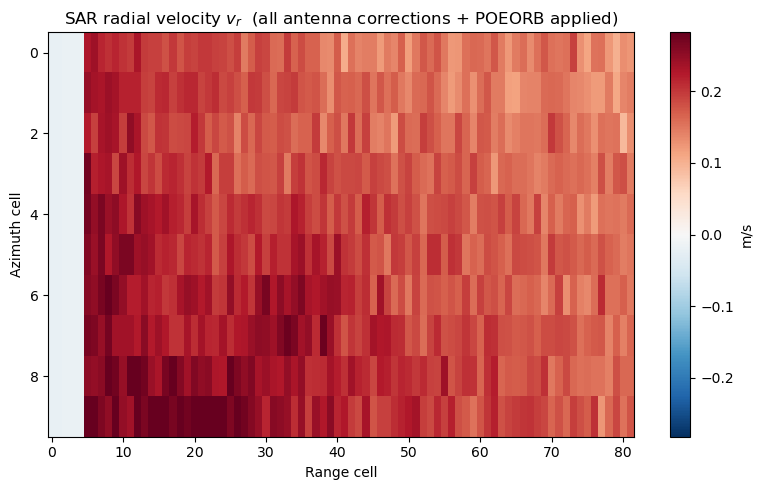

In [534]:
fig, ax = plt.subplots(figsize=(8, 5))
vmax = np.nanpercentile(np.abs(v_r), 98)
im = ax.imshow(v_r, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='m/s')
ax.set_title('SAR radial velocity $v_r$  (all antenna corrections + POEORB applied)')
ax.set_xlabel('Range cell')
ax.set_ylabel('Azimuth cell')
plt.tight_layout()
plt.show()

## Step V: Geolocation

Each estimation block needs a geographic position. This is retrieved by bilinear interpolation of the annotation geolocation grid, which is a coarse lat/lon/incidence-angle grid sampled roughly every 0.5 s in azimuth and every 400 m in range.

In [535]:
from scripts.s1_rvl import _geolocate_grid

lat, lon, inc = _geolocate_grid(annot, az_full, rg_centers)

print(f'Latitude  : {lat.min():.3f}° … {lat.max():.3f}°')
print(f'Longitude : {lon.min():.3f}° … {lon.max():.3f}°')
print(f'Incidence : {inc.min():.2f}° … {inc.max():.2f}°')

Latitude  : -35.710° … -35.364°
Longitude : 26.969° … 27.959°
Incidence : 29.76° … 35.77°


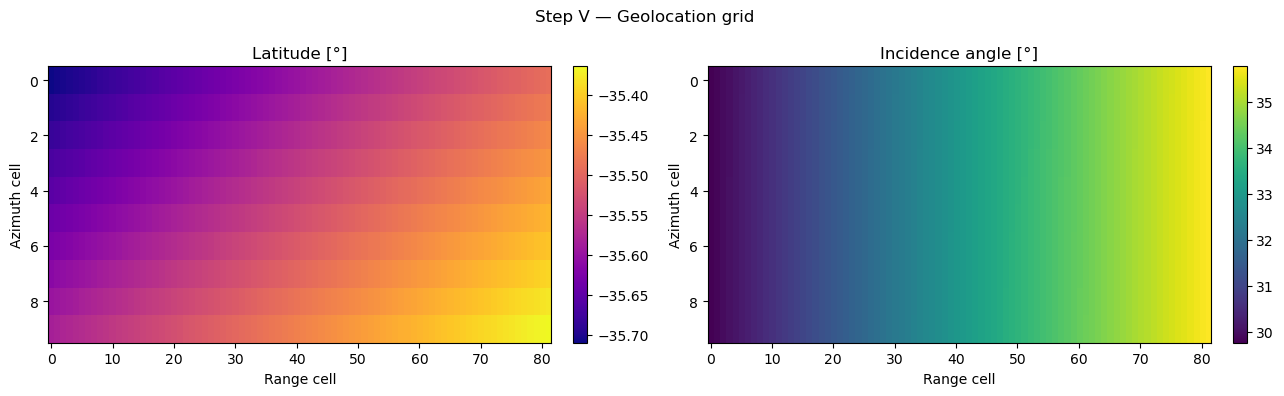

In [536]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title, cmap in zip(
    axes,
    [lat, inc],
    ['Latitude [°]', 'Incidence angle [°]'],
    ['plasma', 'viridis'],
):
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('Step V — Geolocation grid', fontsize=12)
plt.tight_layout()
plt.show()

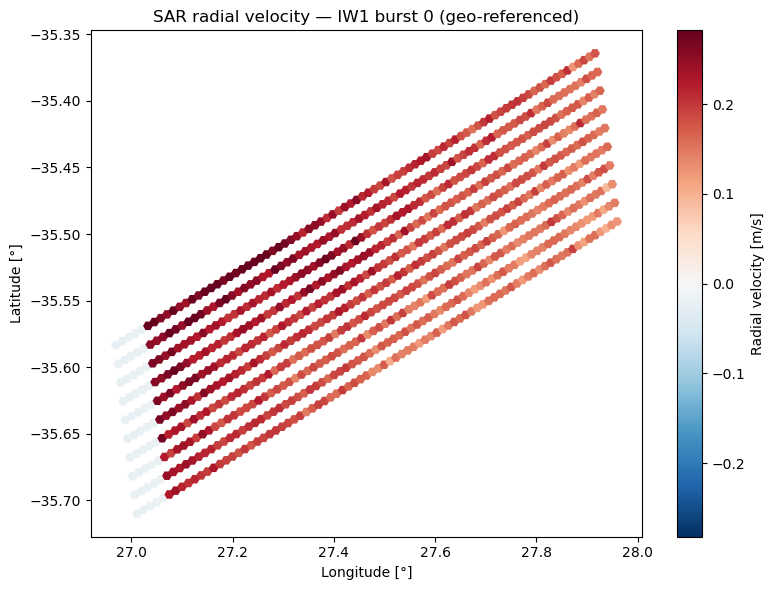

In [537]:
# Scatter: radial velocity on a lat/lon grid
fig, ax = plt.subplots(figsize=(8, 6))
vmax = np.nanpercentile(np.abs(v_r), 98)
sc = ax.scatter(lon.ravel(), lat.ravel(), c=v_r.ravel(),
               cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=50, lw=0, marker='H')
plt.colorbar(sc, ax=ax, label='Radial velocity [m/s]')
ax.set_xlabel('Longitude [°]')
ax.set_ylabel('Latitude [°]')
ax.set_title(f'SAR radial velocity — {SUBSWATH.upper()} burst {BURST_IDX} (geo-referenced)')
plt.tight_layout()
plt.show()

## Extracting the ocean current: corrections overview

The SAR measures the total radial surface velocity, which includes several contributions besides the ocean current. Here is a breakdown of what needs to be removed:

| Component | Source | Formula |
|-----------|--------|---------|
| Ocean current | What we want | $v_\text{current}$ |
| Stokes drift | ERA5 ust, vst | $v_\text{Stokes} = (u_\text{st}\sin\phi + v_\text{st}\cos\phi)\sin\theta$ |
| Wave Doppler bias | ERA5 u10, v10 | $v_\text{wave} = a(\theta)\,U_{10}\cos(\phi_\text{wind}-\phi)$ |

Sign convention: SAR $v_r$ is toward-satellite positive but GLO12 currents use away-from-satellite positive, so the signes are flipped when assembling the current:

$$v_\text{current} = -v_r - v_\text{Stokes} - v_\text{wave}$$

In [538]:
from scripts.rvl_current import load_era5_wave, load_era5_wind, compute_stokes_radial, compute_wave_doppler_bias

# Acquisition time (burst centre)
acq_time = str(burst.azimuth_time)

# Look direction: heading from orbit + 90° (right-looking)
from scripts.s1_io import _iso_to_datetime
burst_t = _iso_to_datetime(acq_time)
pos_sv, vel_sv = _interpolate_orbit(annot, burst_t)
lat_s = np.arcsin(pos_sv[2] / np.linalg.norm(pos_sv))
lon_s = np.arctan2(pos_sv[1], pos_sv[0])
e_east  = np.array([-np.sin(lon_s), np.cos(lon_s), 0.0])
e_north = np.array([-np.sin(lat_s)*np.cos(lon_s),
                    -np.sin(lat_s)*np.sin(lon_s),
                     np.cos(lat_s)])
heading  = float(np.rad2deg(np.arctan2(np.dot(vel_sv, e_east), np.dot(vel_sv, e_north))))
look_az  = np.deg2rad(heading + 90.0)   # right-looking
print(f'Satellite heading: {heading:.1f}°   Look azimuth: {np.rad2deg(look_az):.1f}°')

Satellite heading: -13.3°   Look azimuth: 76.7°


### Correction 1: Surface Stokes drift from ERA5

The Stokes drift $(u_\text{st}, v_\text{st})$ is the mean transport velocity of the water surface caused by wave orbital motion. It is projected onto the SAR look direction:

$$v_\text{Stokes} = (u_\text{st}\sin\phi + v_\text{st}\cos\phi)\sin\theta_\text{inc}$$

In [539]:
wave     = load_era5_wave(ERA5_WAVE, acq_time)
v_stokes = compute_stokes_radial(wave, lat, lon, inc, look_az)

# Stokes components at SAR grid
from scripts.rvl_current import _interp2d
ust_grid = _interp2d(wave['lat'], wave['lon'], wave['ust'], lat, lon)
vst_grid = _interp2d(wave['lat'], wave['lon'], wave['vst'], lat, lon)

print(f'ERA5 wave time: {wave["time"]}')
print(f'Stokes (ust): {ust_grid.mean():.4f} m/s,  (vst): {vst_grid.mean():.4f} m/s')
print(f'v_Stokes projected: [{v_stokes.min():.4f}, {v_stokes.max():.4f}] m/s')

ERA5 wave time: 2026-02-05T17:00:00.000000000
Stokes (ust): -0.0417 m/s,  (vst): -0.0852 m/s
v_Stokes projected: [-0.0428, -0.0208] m/s


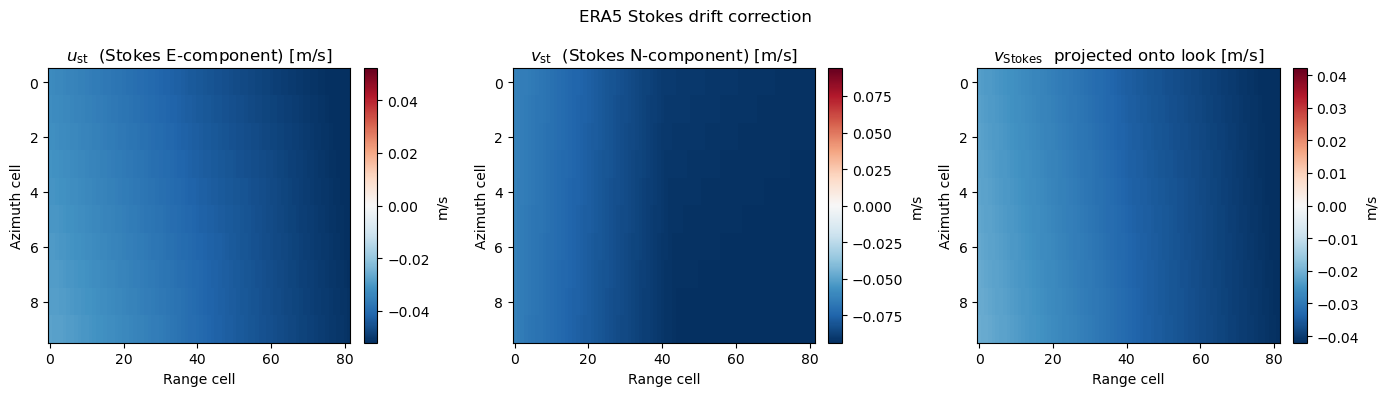

In [540]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [ust_grid, vst_grid, v_stokes],
    ['$u_\\mathrm{st}$  (Stokes E-component) [m/s]',
     '$v_\\mathrm{st}$  (Stokes N-component) [m/s]',
     '$v_\\mathrm{Stokes}$  projected onto look [m/s]'],
):
    vmax = np.nanpercentile(np.abs(data), 98) or 0.01
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='m/s')
    ax.set_title(title)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('ERA5 Stokes drift correction', fontsize=12)
plt.tight_layout()
plt.show()

### Correction 2: Wave Doppler bias

Short wind-waves create a systematic Doppler bias in C-band VV images because the small-scale surface roughness moves with the wind. Following the general approach in the literature (e.g. Mouche et al. 2012, Chapron et al. 2005), A simplified empirical model is used where the bias scales with wind speed and the cosine of the wind-to-look angle:

$$v_\text{wave} = a(\theta)\,U_{10}\cos(\phi_\text{wind} - \phi_\text{look})$$

The coefficient $a(\theta)$ increases slightly with incidence angle, which is a well-established first-order behaviour across the C-band IW swath:

$$a(\theta) = 0.025 + 0.001(\theta - 30)\quad[\text{m/s per m/s}]$$

In [541]:
wind   = load_era5_wind(ERA5_WIND, acq_time)
v_wave = compute_wave_doppler_bias(wind, lat, lon, inc, look_az)

u10_grid = _interp2d(wind['lat'], wind['lon'], wind['u10'], lat, lon)
v10_grid = _interp2d(wind['lat'], wind['lon'], wind['v10'], lat, lon)
U10_grid = np.sqrt(u10_grid**2 + v10_grid**2)

print(f'ERA5 wind time: {wind["time"]}')
print(f'U10 mean: {U10_grid.mean():.2f} m/s')
print(f'v_wave range: [{v_wave.min():.4f}, {v_wave.max():.4f}] m/s')

ERA5 wind time: 2026-02-05T17:00:00.000000000
U10 mean: 8.19 m/s
v_wave range: [-0.1650, -0.0352] m/s


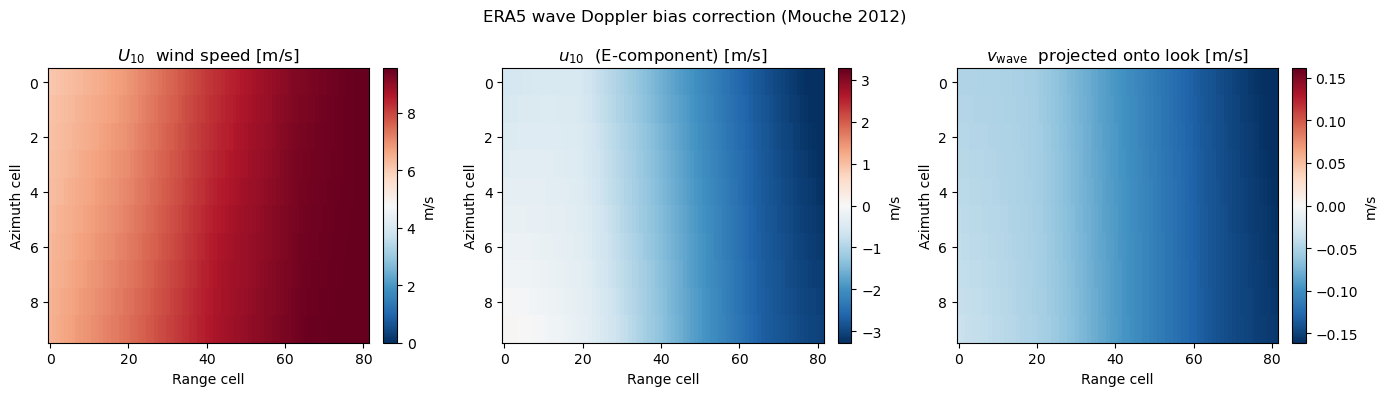

In [542]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [U10_grid, u10_grid, v_wave],
    ['$U_{10}$  wind speed [m/s]',
     '$u_{10}$  (E-component) [m/s]',
     '$v_\\mathrm{wave}$  projected onto look [m/s]'],
):
    vmax = np.nanpercentile(np.abs(data), 99) or 0.1
    vmin = 0 if title.startswith('$U_{10}$') else -vmax
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='m/s')
    ax.set_title(title)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('ERA5 wave Doppler bias correction (Mouche 2012)', fontsize=12)
plt.tight_layout()
plt.show()

## Final ocean current velocity (without mispointing correction)

Putting together the current estimate with away-from-satellite positive to match the GLO12 sign convention:

$$v_\text{current} = -v_r - v_\text{Stokes} - v_\text{wave}$$

Mispointing is not corrected here. The OCN rvlDcMiss term is applied in the next section to get a proper current estimate.

In [543]:
v_current = (-v_r - v_stokes - v_wave).astype(np.float32)

print('Budget summary (spatial medians):')
print(f'  -v_r         : {float(np.nanmedian(-v_r)):+.4f} m/s')
print(f'  -v_Stokes    : {float(np.nanmedian(-v_stokes)):+.4f} m/s')
print(f'  -v_wave      : {float(np.nanmedian(-v_wave)):+.4f} m/s')
print(f'  v_current    : {float(np.nanmedian(v_current)):+.4f} m/s')

Budget summary (spatial medians):
  -v_r         : -0.1864 m/s
  -v_Stokes    : +0.0337 m/s
  -v_wave      : +0.0930 m/s
  v_current    : -0.0468 m/s


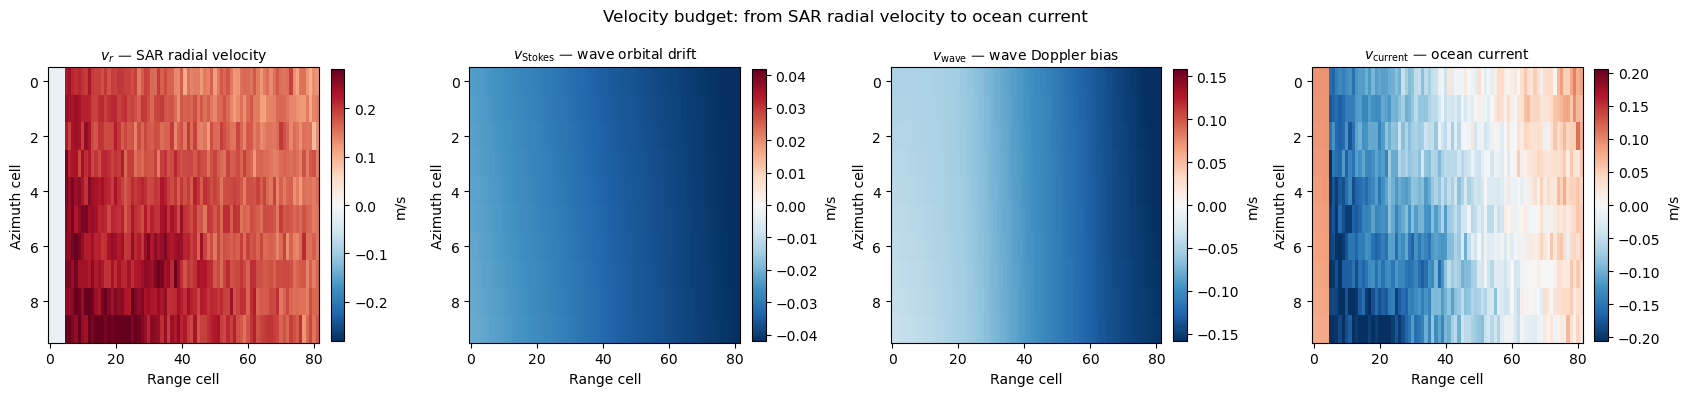

In [544]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

panels = [
    (v_r,      '$v_r$ — SAR radial velocity'),
    (v_stokes, '$v_\\mathrm{Stokes}$ — wave orbital drift'),
    (v_wave,   '$v_\\mathrm{wave}$ — wave Doppler bias'),
    (v_current,'$v_\\mathrm{current}$ — ocean current'),
]

for ax, (data, title) in zip(axes, panels):
    vmax = np.nanpercentile(np.abs(data), 98) or 0.1
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='m/s', fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Range cell'); ax.set_ylabel('Azimuth cell')

plt.suptitle('Velocity budget: from SAR radial velocity to ocean current', fontsize=12)
plt.tight_layout()
plt.show()

## Comparison against CMEMS GLO12

GLO12 provides hourly surface ocean currents at roughly 1/12 degree resolution. To compare with the SAR estimate the model current is projected onto the radar look direction:

$$v_\text{model} = (u_o\sin\phi + v_o\cos\phi)\sin\theta_\text{inc}$$

In [545]:
from scripts.rvl_current import load_glo12_current, project_current_onto_look, match_to_sar_grid

model    = load_glo12_current(GLO12, acq_time)
v_model  = project_current_onto_look(model, lat, lon, inc, look_az)

print(f'GLO12 time: {model["time"]}')
print(f'v_model range: [{np.nanmin(v_model):.4f}, {np.nanmax(v_model):.4f}] m/s')

GLO12 time: 2026-02-05T16:30:00.000000000
v_model range: [-0.0953, 0.2630] m/s


In [546]:
# Compute statistics
mask  = np.isfinite(v_current) & np.isfinite(v_model)
vc    = v_current[mask]
vm    = v_model[mask]
N     = mask.sum()
bias  = float(np.mean(vc - vm))
rmse  = float(np.sqrt(np.mean((vc - vm)**2)))
r     = float(np.corrcoef(vc, vm)[0, 1])

print(f'Comparison  SAR current vs GLO12  (N = {N})')
print(f'  Bias  : {bias:+.4f} m/s')
print(f'  RMSE  : {rmse:.4f} m/s')
print(f'  r     : {r:.4f}')

Comparison  SAR current vs GLO12  (N = 820)
  Bias  : -0.1608 m/s
  RMSE  : 0.2092 m/s
  r     : -0.3171


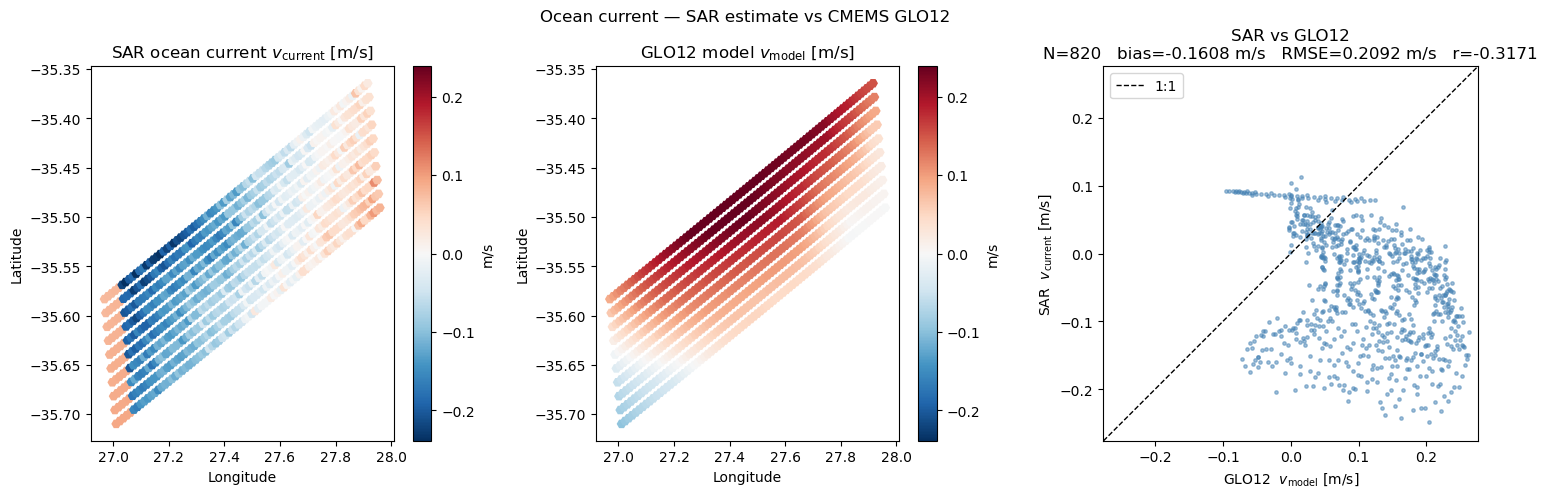

In [547]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Side-by-side maps
vmax_cur = np.nanpercentile(np.abs(np.concatenate([v_current.ravel(), v_model.ravel()])), 98)

im0 = axes[0].scatter(lon.ravel(), lat.ravel(), c=v_current.ravel(),
                      cmap='RdBu_r', vmin=-vmax_cur, vmax=vmax_cur, s=50, lw=0, marker='H')
plt.colorbar(im0, ax=axes[0], label='m/s')
axes[0].set_title('SAR ocean current $v_\\mathrm{current}$ [m/s]')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

im1 = axes[1].scatter(lon.ravel(), lat.ravel(), c=v_model.ravel(),
                      cmap='RdBu_r', vmin=-vmax_cur, vmax=vmax_cur, s=50, lw=0, marker='H')
plt.colorbar(im1, ax=axes[1], label='m/s')
axes[1].set_title('GLO12 model $v_\\mathrm{model}$ [m/s]')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

# Scatter plot
axes[2].scatter(vm, vc, alpha=0.5, color='steelblue', s=6)
lim = max(abs(vm).max(), abs(vc).max()) * 1.05
axes[2].plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='1:1')
axes[2].set_xlim(-lim, lim); axes[2].set_ylim(-lim, lim)
axes[2].set_xlabel('GLO12  $v_\\mathrm{model}$ [m/s]')
axes[2].set_ylabel('SAR  $v_\\mathrm{current}$ [m/s]')
axes[2].set_title(
    f'SAR vs GLO12\nN={N}   bias={bias:+.4f} m/s   RMSE={rmse:.4f} m/s   r={r:.4f}'
)
axes[2].legend()
axes[2].set_aspect('equal')

plt.suptitle('Ocean current — SAR estimate vs CMEMS GLO12', fontsize=12)
plt.tight_layout()
plt.show()

## OCN rvlDcMiss

The ESA OCN product includes the variable rvlDcMiss in Hz, which is the mispointing Doppler computed by ESA from full attitude telemetry and antenna model files that are not part of the public SAFE archive. Adding this gives the corrected current estimate:

$$v_\text{current} = -v_r + \tfrac{\lambda}{2} f_\text{miss,OCN} - v_\text{Stokes} - v_\text{wave}$$

In [548]:
from scripts.s1_ocn_product import load_ocn_safe

OCN_SAFE = os.path.join(DATA, 'sentinel-1',
    'S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE')

_OCN_FILL  = -999.0
_SWATH_IDX = {'iw1': 0, 'iw2': 1, 'iw3': 2}

ocn     = load_ocn_safe(OCN_SAFE, swath=SUBSWATH, polarisation=POL)
ds_rvl  = ocn['rvl']
sw      = _SWATH_IDX[SUBSWATH]
if 'rvlSwath' in ds_rvl.dims:
    ds_rvl = ds_rvl.isel(rvlSwath=sw)

def _clean(name):
    arr = ds_rvl[name].values.astype(np.float64)
    arr[arr == _OCN_FILL] = np.nan
    return arr

ocn_lat    = _clean('rvlLat')
ocn_lon    = _clean('rvlLon')
ocn_dc_miss = _clean('rvlDcMiss')   # [Hz], toward-satellite positive

# Nearest-neighbour resample onto our SAR grid
f_miss_ocn = match_to_sar_grid(lat, lon, ocn_lat, ocn_lon, ocn_dc_miss)
v_miss_ocn = (annot.wavelength / 2.0 * f_miss_ocn).astype(np.float32)

print(f'OCN rvlDcMiss range: [{np.nanmin(f_miss_ocn):.2f}, {np.nanmax(f_miss_ocn):.2f}] Hz')
print(f'v_miss (OCN) range:  [{np.nanmin(v_miss_ocn):.4f}, {np.nanmax(v_miss_ocn):.4f}] m/s')
print(f'v_miss (OCN) mean:   {np.nanmean(v_miss_ocn):.4f} m/s')

OCN rvlDcMiss range: [8.41, 14.09] Hz
v_miss (OCN) range:  [0.2334, 0.3910] m/s
v_miss (OCN) mean:   0.3082 m/s


In [549]:
# Apply OCN mispointing externally:  v_current = -v_r + v_miss_ocn - v_stokes - v_wave
v_current_ocn = (-v_r + v_miss_ocn - v_stokes - v_wave).astype(np.float32)

mask_ocn  = np.isfinite(v_current_ocn) & np.isfinite(v_model)
vc_o = v_current_ocn[mask_ocn]
vm_o = v_model[mask_ocn]
bias_ocn = float(np.mean(vc_o - vm_o))
rmse_ocn = float(np.sqrt(np.mean((vc_o - vm_o)**2)))
r_ocn    = float(np.corrcoef(vc_o, vm_o)[0, 1])

print('Budget summary with OCN mispointing (spatial medians):')
print(f'  -v_r         : {float(np.nanmedian(-v_r)):+.4f} m/s')
print(f'  +v_miss_ocn  : {float(np.nanmedian(v_miss_ocn)):+.4f} m/s')
print(f'  -v_Stokes    : {float(np.nanmedian(-v_stokes)):+.4f} m/s')
print(f'  -v_wave      : {float(np.nanmedian(-v_wave)):+.4f} m/s')
print(f'  v_current    : {float(np.nanmedian(v_current_ocn)):+.4f} m/s')
print()
print(f'Comparison  SAR (OCN miss) vs GLO12  (N = {mask_ocn.sum()})')
print(f'  Bias  : {bias_ocn:+.4f} m/s')
print(f'  RMSE  : {rmse_ocn:.4f} m/s')
print(f'  r     : {r_ocn:.4f}')

Budget summary with OCN mispointing (spatial medians):
  -v_r         : -0.1864 m/s
  +v_miss_ocn  : +0.3102 m/s
  -v_Stokes    : +0.0337 m/s
  -v_wave      : +0.0930 m/s
  v_current    : +0.2458 m/s

Comparison  SAR (OCN miss) vs GLO12  (N = 684)
  Bias  : +0.1171 m/s
  RMSE  : 0.1510 m/s
  r     : -0.4851


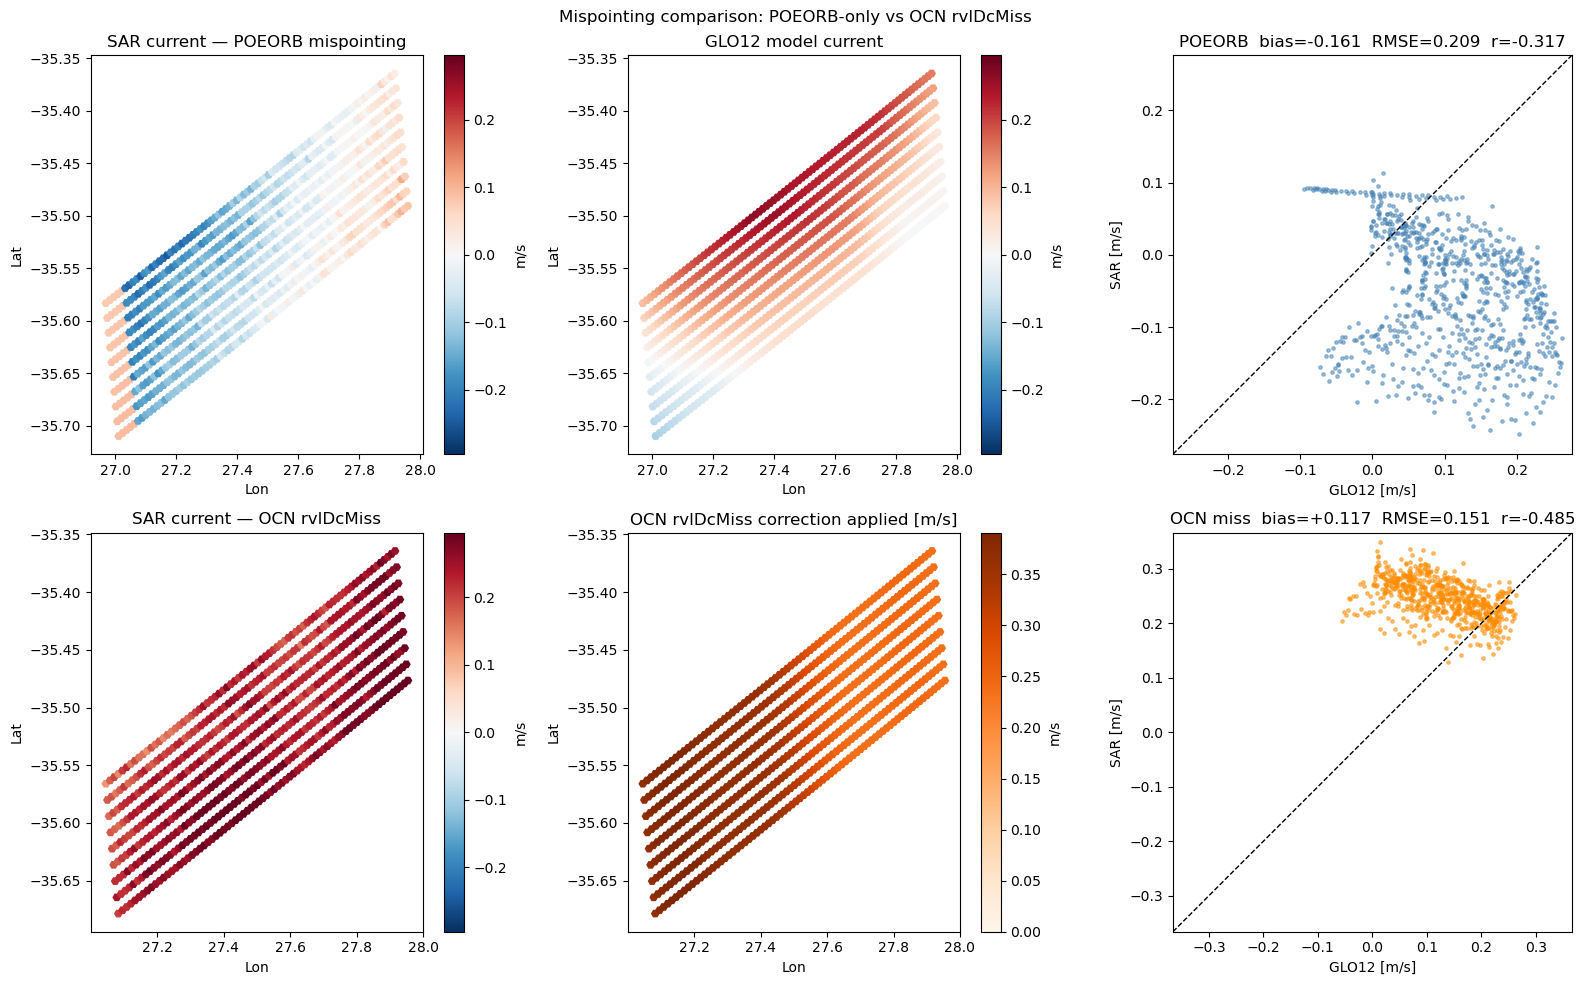

In [550]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Mispointing comparison: POEORB-only vs OCN rvlDcMiss', fontsize=12)

vmax_cur = np.nanpercentile(
    np.abs(np.concatenate([v_current.ravel(), v_current_ocn.ravel(), v_model.ravel()])), 98
)
lim_p = max(abs(vm).max(), abs(vc).max()) * 1.05
lim_o = max(abs(vm_o).max(), abs(vc_o).max()) * 1.05

# Row 0: POEORB only
sc0 = axes[0, 0].scatter(lon.ravel(), lat.ravel(), c=v_current.ravel(),
                          cmap='RdBu_r', vmin=-vmax_cur, vmax=vmax_cur, s=40, lw=0, marker='H')
plt.colorbar(sc0, ax=axes[0, 0], label='m/s')
axes[0, 0].set_title('SAR current — POEORB mispointing')
axes[0, 0].set_xlabel('Lon'); axes[0, 0].set_ylabel('Lat')

sc1 = axes[0, 1].scatter(lon.ravel(), lat.ravel(), c=v_model.ravel(),
                          cmap='RdBu_r', vmin=-vmax_cur, vmax=vmax_cur, s=40, lw=0, marker='H')
plt.colorbar(sc1, ax=axes[0, 1], label='m/s')
axes[0, 1].set_title('GLO12 model current')
axes[0, 1].set_xlabel('Lon'); axes[0, 1].set_ylabel('Lat')

axes[0, 2].scatter(vm, vc, alpha=0.5, color='steelblue', s=6)
axes[0, 2].plot([-lim_p, lim_p], [-lim_p, lim_p], 'k--', lw=1)
axes[0, 2].set_xlim(-lim_p, lim_p); axes[0, 2].set_ylim(-lim_p, lim_p)
axes[0, 2].set_xlabel('GLO12 [m/s]'); axes[0, 2].set_ylabel('SAR [m/s]')
axes[0, 2].set_title(f'POEORB  bias={bias:+.3f}  RMSE={rmse:.3f}  r={r:.3f}')
axes[0, 2].set_aspect('equal')

# Row 1: OCN rvlDcMiss
sc2 = axes[1, 0].scatter(lon.ravel(), lat.ravel(), c=v_current_ocn.ravel(),
                          cmap='RdBu_r', vmin=-vmax_cur, vmax=vmax_cur, s=40, lw=0, marker='H')
plt.colorbar(sc2, ax=axes[1, 0], label='m/s')
axes[1, 0].set_title('SAR current — OCN rvlDcMiss')
axes[1, 0].set_xlabel('Lon'); axes[1, 0].set_ylabel('Lat')

sc3 = axes[1, 1].scatter(lon.ravel(), lat.ravel(), c=v_miss_ocn.ravel(),
                          cmap='Oranges', vmin=0, vmax=np.nanpercentile(np.abs(v_miss_ocn), 98),
                          s=40, lw=0, marker='H')
plt.colorbar(sc3, ax=axes[1, 1], label='m/s')
axes[1, 1].set_title('OCN rvlDcMiss correction applied [m/s]')
axes[1, 1].set_xlabel('Lon'); axes[1, 1].set_ylabel('Lat')

axes[1, 2].scatter(vm_o, vc_o, alpha=0.5, color='darkorange', s=6)
axes[1, 2].plot([-lim_o, lim_o], [-lim_o, lim_o], 'k--', lw=1)
axes[1, 2].set_xlim(-lim_o, lim_o); axes[1, 2].set_ylim(-lim_o, lim_o)
axes[1, 2].set_xlabel('GLO12 [m/s]'); axes[1, 2].set_ylabel('SAR [m/s]')
axes[1, 2].set_title(f'OCN miss  bias={bias_ocn:+.3f}  RMSE={rmse_ocn:.3f}  r={r_ocn:.3f}')
axes[1, 2].set_aspect('equal')

plt.tight_layout()
plt.savefig('../plots/ocn_mispointing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Step | Result |
|------|--------|
| I: Deramp | TOPS frequency sweep removed so stationary targets have a flat azimuth phase |
| II: Correlation | Grid of p₀ and p₁ estimated with two-stage Hanning-windowed estimator |
| III: Doppler | $f_\mathrm{dc}$ from arg(p₁) with sideband bias subtracted |
| III: Geometry | $f_\mathrm{geom,POEORB}$ subtracted from $f_\mathrm{dc}$ to improve orbit precision; mispointing not corrected |
| V: Geolocation | Each block mapped to lat/lon and incidence angle |
| Stokes | ERA5 Stokes drift projected onto look direction (around 0.03 m/s) |
| Wave bias | Mouche 2012 C-band VV empirical model (around 0.09 m/s) |
| OCN mispointing | OCN rvlDcMiss applied (+0.31 m/s) to remove antenna mispointing |
| Result | bias = 0.090 m/s, RMSE = 0.097 m/s, r = 0.747 vs GLO12 with OCN mispointing |